In [1]:
!pip install pandas scikit-learn matplotlib seaborn xgboost openpyxl


   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB 660.6 kB/s eta 0:01:26
   ---------------------------------------- 0.0/56.8 MB 495.5 kB/s eta 0:01:55
   ---------------------------------------- 0.1/56.8 MB 469.7 kB/s eta 0:02:01
   ---------------------------------------- 0.1/56.8 MB 476.3 kB/s eta 0:02:00
   ---------------------------------------- 0.1/56.8 MB 469.7 kB/s eta 0:02:01
   ---------------------------------------- 0.1/56.8 MB 473.7 kB/s eta 0:02:00
   ---------------------------------------- 0.2/56.8 MB 459.5 kB/s eta 0:02:04
   ---------------------------------------- 0.2/56.8 MB 491.5 kB/s eta 0:01:56
   ---------------------------------------- 0.2/56.8 MB 479.2 kB/s eta 0:01:59
   ------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.cluster import KMeans


In [5]:

df = pd.read_excel(r"C:\Claims_Data.xlsx")


In [7]:
employee_stats = df.groupby('CPF NO').agg({
    'AMOUNT': ['count', 'sum', 'mean', 'max'],
    'TREATMENT': 'nunique',
    'ILLNESS': 'nunique',
    'AGE': 'first',
    'RELATION': 'first',
    'GENDER': 'first'
}).reset_index()
employee_stats.columns = ['CPF NO', 'claim_count', 'total_amount', 'mean_amount', 'max_amount',
                         'unique_treatments', 'unique_illness', 'AGE', 'RELATION', 'GENDER']


In [9]:
employee_stats['high_cost'] = (employee_stats['total_amount'] > employee_stats['total_amount'].quantile(0.8)).astype(int)


In [11]:
employee_stats['frequent'] = (employee_stats['claim_count'] > employee_stats['claim_count'].quantile(0.75)).astype(int)


In [13]:
features = ['claim_count', 'mean_amount', 'max_amount', 'unique_treatments', 'unique_illness', 'AGE']
X = employee_stats[features]


In [15]:
y_high = employee_stats['high_cost']
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X, y_high)
employee_stats['prob_high_claim'] = rf_model.predict_proba(X)[:,1]


In [19]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X, y_freq)
employee_stats['prob_frequent'] = lr_model.predict_proba(X)[:,1]
employee_stats['frequent_pred'] = lr_model.predict(X)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_scaled, y_freq)
employee_stats['prob_frequent'] = lr_model.predict_proba(X_scaled)[:,1]
employee_stats['frequent_pred'] = lr_model.predict(X_scaled)


In [25]:
from sklearn.cluster import KMeans

cluster_features = ['claim_count', 'unique_illness', 'total_amount']
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(employee_stats[cluster_features])

employee_stats['risk_segment'] = clusters

# Check which cluster corresponds to Low/Med/High risk
print(employee_stats.groupby('risk_segment')[cluster_features].mean())

# Adjust cluster_map after checking the print output above!
cluster_map = {0: 'Low', 1: 'Medium', 2: 'High'}
employee_stats['risk_label'] = employee_stats['risk_segment'].map(cluster_map)


D:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


              claim_count  unique_illness   total_amount
risk_segment                                            
0                6.678571        5.785714   98369.178571
1                3.442857        3.000000   25766.814286
2               14.400000        8.800000  233197.000000


In [27]:
cluster_map = {1: 'Low', 0: 'Medium', 2: 'High'}
employee_stats['risk_label'] = employee_stats['risk_segment'].map(cluster_map)


In [29]:
from sklearn.linear_model import Ridge

y_cost = employee_stats['total_amount']
ridge = Ridge()
ridge.fit(X, y_cost)
employee_stats['predicted_cost'] = ridge.predict(X)


In [33]:
employee_stats.to_excel("employee_predictions.xlsx", index=False)


<Axes: xlabel='count', ylabel='risk_label'>

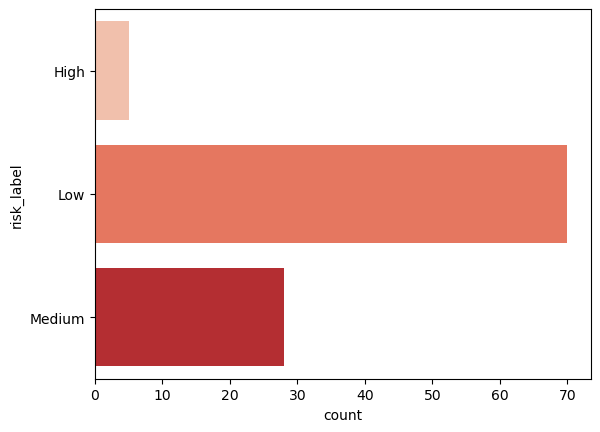

In [37]:
sns.countplot(y='risk_label', data=employee_stats, palette='Reds', hue='risk_label', legend=False)


In [39]:
top_cost = employee_stats[['CPF NO', 'predicted_cost', 'risk_label', 'prob_high_claim']].sort_values('predicted_cost', ascending=False).head(10)
print("Top 10 Employees by Predicted Future Cost:")
print(top_cost)


Top 10 Employees by Predicted Future Cost:
     CPF NO  predicted_cost risk_label  prob_high_claim
14   265479   229097.955349       High             0.98
67   755129   204513.259410       High             0.92
8    186107   190395.552979       High             0.95
0     20659   189911.065754       High             0.89
73   786712   187255.048479       High             0.91
80   847119   180461.223185     Medium             0.77
62   717288   132536.146453     Medium             0.14
102  998734   126442.227442     Medium             0.75
60   716123   116945.473255     Medium             0.94
66   753994   115689.447238     Medium             0.88


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16512\3691014921.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='frequent_pred', data=employee_stats, palette='Blues')


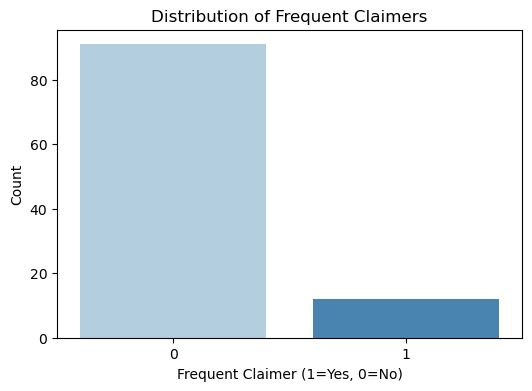

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x='frequent_pred', data=employee_stats, palette='Blues')
plt.title("Distribution of Frequent Claimers")
plt.xlabel("Frequent Claimer (1=Yes, 0=No)")
plt.ylabel("Count")
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16512\3737791544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risk_label', y='predicted_cost', data=employee_stats, palette='Pastel1')


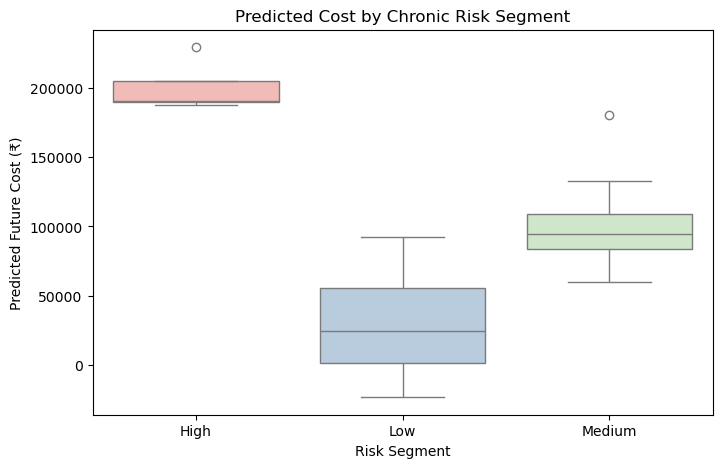

In [43]:
plt.figure(figsize=(8,5))
sns.boxplot(x='risk_label', y='predicted_cost', data=employee_stats, palette='Pastel1')
plt.title('Predicted Cost by Chronic Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('Predicted Future Cost (₹)')
plt.show()


In [45]:
for risk in ['High', 'Medium', 'Low']:
    print(f"\nTop 5 in {risk} risk segment:")
    display(employee_stats[employee_stats['risk_label']==risk].sort_values('predicted_cost', ascending=False).head(5)[
        ['CPF NO', 'predicted_cost', 'total_amount', 'prob_high_claim', 'prob_frequent']
    ])



Top 5 in High risk segment:


,CPF NO,predicted_cost,total_amount,prob_high_claim,prob_frequent
14,265479,229097.955349,278517,0.98,0.999891
67,755129,204513.259410,227415,0.92,0.998093
8,186107,190395.552979,271894,0.95,0.898184
0,20659,189911.065754,175164,0.89,0.997100
73,786712,187255.048479,212995,0.91,0.996997



Top 5 in Medium risk segment:


,CPF NO,predicted_cost,total_amount,prob_high_claim,prob_frequent
80,847119,180461.223185,152896,0.77,0.999258
62,717288,132536.146453,63320,0.14,0.995818
102,998734,126442.227442,121670,0.75,0.991043
60,716123,116945.473255,139192,0.94,0.091769
66,753994,115689.447238,128512,0.88,0.023806



Top 5 in Low risk segment:


,CPF NO,predicted_cost,total_amount,prob_high_claim,prob_frequent
51,606421,92169.311473,58309,0.06,0.000838
77,809822,84101.177522,28136,0.01,0.000123
64,747019,78602.290936,47893,0.03,0.238975
49,575912,72077.342288,57608,0.02,0.001890
55,664576,70323.814562,42990,0.00,0.000480


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16512\3127805509.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risk_label', y='claim_count', data=employee_stats, palette='Set2')


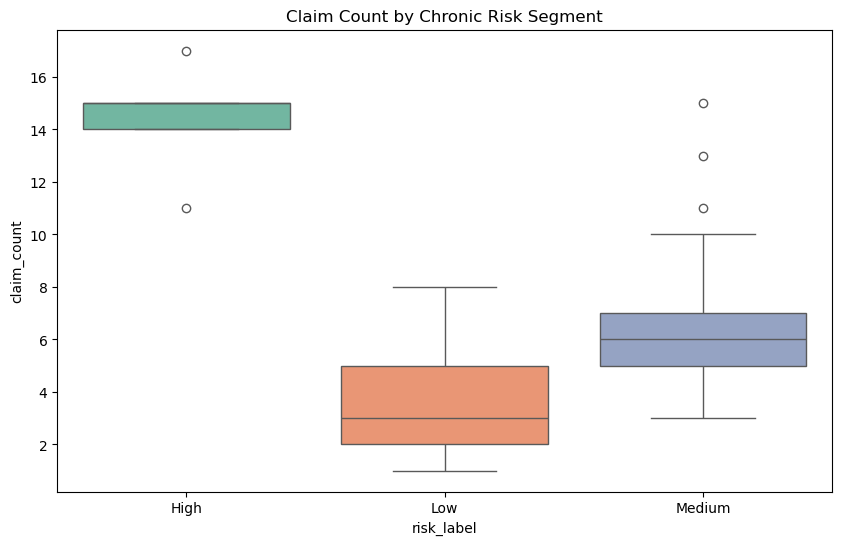

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16512\3127805509.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risk_label', y='unique_illness', data=employee_stats, palette='Set3')


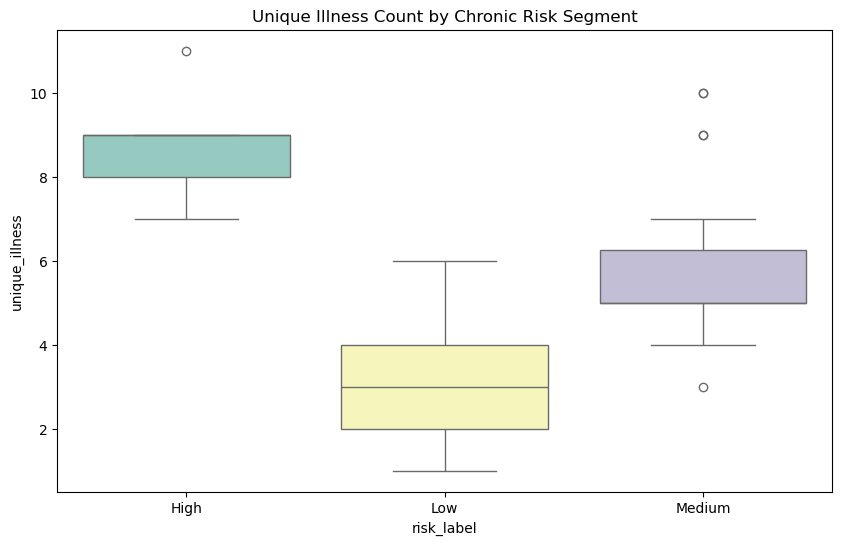

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='risk_label', y='claim_count', data=employee_stats, palette='Set2')
plt.title('Claim Count by Chronic Risk Segment')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='risk_label', y='unique_illness', data=employee_stats, palette='Set3')
plt.title('Unique Illness Count by Chronic Risk Segment')
plt.show()


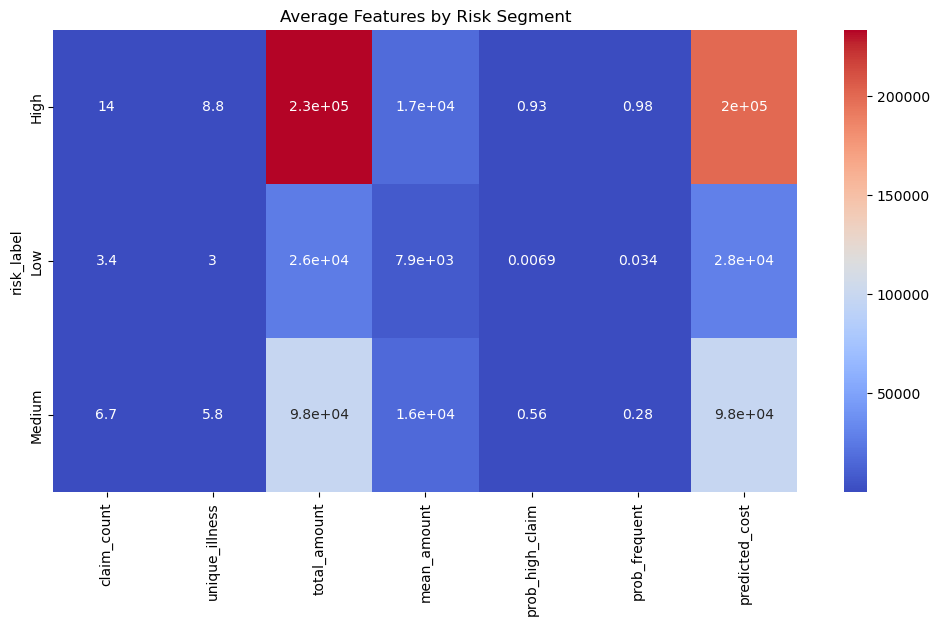

In [49]:
segment_means = employee_stats.groupby('risk_label')[['claim_count', 'unique_illness', 'total_amount', 'mean_amount', 'prob_high_claim', 'prob_frequent', 'predicted_cost']].mean()
plt.figure(figsize=(12,6))
sns.heatmap(segment_means, annot=True, cmap='coolwarm')
plt.title('Average Features by Risk Segment')
plt.show()


In [51]:
contradictory = employee_stats[(employee_stats['risk_label']=='High') & (employee_stats['predicted_cost'] < employee_stats['predicted_cost'].quantile(0.5))]
print("High-risk segment but low predicted future cost:")
display(contradictory[['CPF NO', 'predicted_cost', 'total_amount', 'prob_high_claim', 'prob_frequent']].head(5))


High-risk segment but low predicted future cost:


,CPF NO,predicted_cost,total_amount,prob_high_claim,prob_frequent


In [53]:
high_intervention = employee_stats[(employee_stats['risk_label']=='High') & (employee_stats['predicted_cost'] > employee_stats['predicted_cost'].quantile(0.8))]
high_intervention.to_excel("high_risk_high_cost_employees.xlsx", index=False)


In [55]:
recommendations = {
    'High': 'Intensive Health Counseling & Monitoring',
    'Medium': 'Regular Checkups & Preventive Care',
    'Low': 'Standard Health Awareness Programs'
}
employee_stats['recommendation'] = employee_stats['risk_label'].map(recommendations)


In [57]:
print(employee_stats[['CPF NO', 'risk_label', 'predicted_cost', 'recommendation']].head(10))


   CPF NO risk_label  predicted_cost                            recommendation
0   20659       High   189911.065754  Intensive Health Counseling & Monitoring
1   38367        Low    -1330.352379        Standard Health Awareness Programs
2   39583        Low    50425.028424        Standard Health Awareness Programs
3   55486        Low    40133.921855        Standard Health Awareness Programs
4   93905        Low   -16399.298441        Standard Health Awareness Programs
5  139429        Low    12277.431131        Standard Health Awareness Programs
6  175322     Medium    84050.618626        Regular Checkups & Preventive Care
7  183143        Low    -9253.724099        Standard Health Awareness Programs
8  186107       High   190395.552979  Intensive Health Counseling & Monitoring
9  199769        Low     2089.284043        Standard Health Awareness Programs


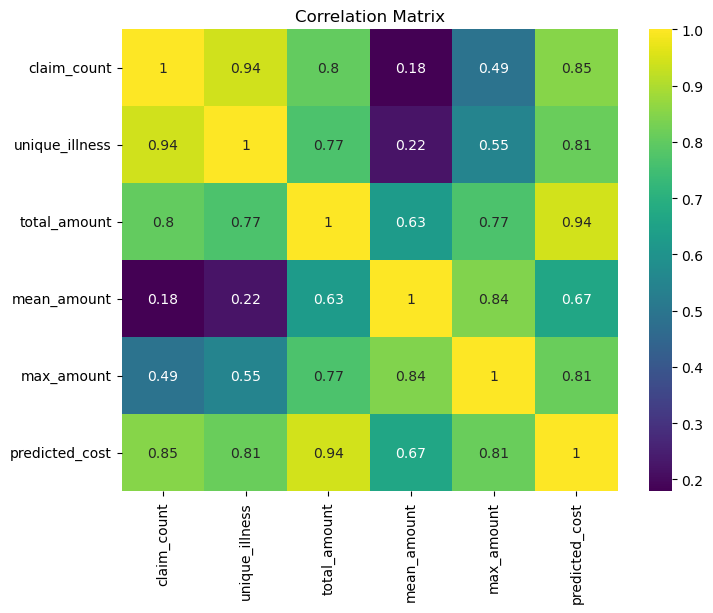

In [59]:
corr = employee_stats[['claim_count', 'unique_illness', 'total_amount', 'mean_amount', 'max_amount', 'predicted_cost']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='viridis')
plt.title('Correlation Matrix')
plt.show()


In [63]:
total_employees = employee_stats.shape[0]
high_risk_count = (employee_stats['risk_label'] == 'High').sum()
freq_count = (employee_stats['frequent_pred'] == 1).sum()
predicted_total_payout = employee_stats['predicted_cost'].sum()

print(f"Total Employees: {total_employees}")
print(f"High Risk: {high_risk_count}")
print(f"Frequent Claimers: {freq_count}")
print(f"Total Predicted Payout (₹): {predicted_total_payout:,.0f}")


Total Employees: 103
High Risk: 5
Frequent Claimers: 12
Total Predicted Payout (₹): 5,723,999


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16512\402099037.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='risk_label', data=employee_stats, palette='Reds')


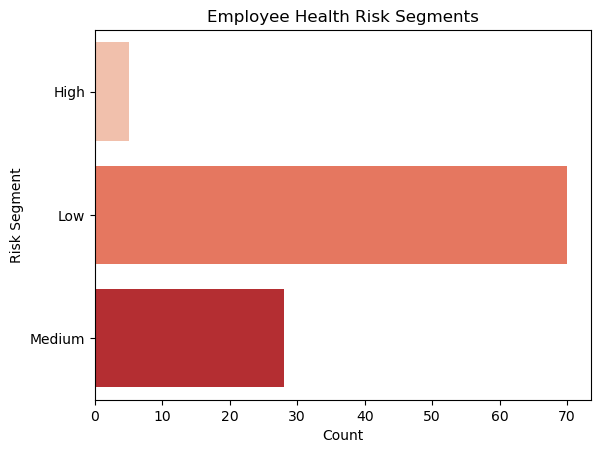

In [65]:
sns.countplot(y='risk_label', data=employee_stats, palette='Reds')
plt.title("Employee Health Risk Segments")
plt.xlabel("Count")
plt.ylabel("Risk Segment")
plt.show()


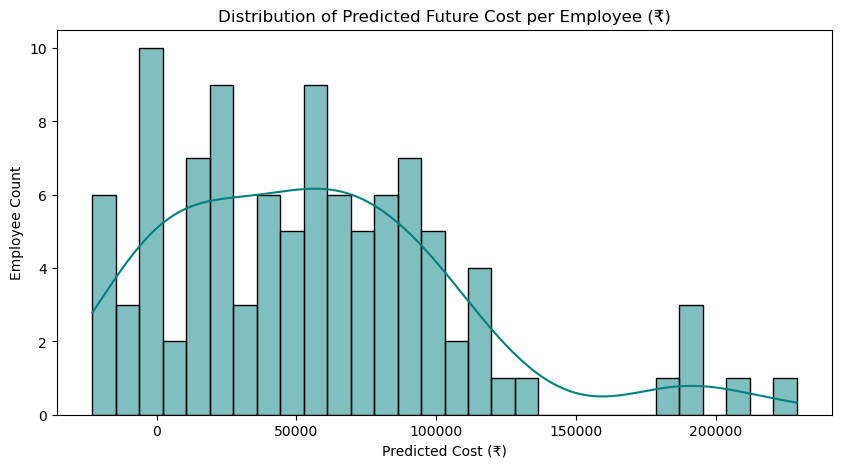

In [67]:
plt.figure(figsize=(10,5))
sns.histplot(employee_stats['predicted_cost'], bins=30, kde=True, color='teal')
plt.title('Distribution of Predicted Future Cost per Employee (₹)')
plt.xlabel('Predicted Cost (₹)')
plt.ylabel('Employee Count')
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16512\845163938.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='risk_label', y='predicted_cost', data=employee_stats, palette='Set2')


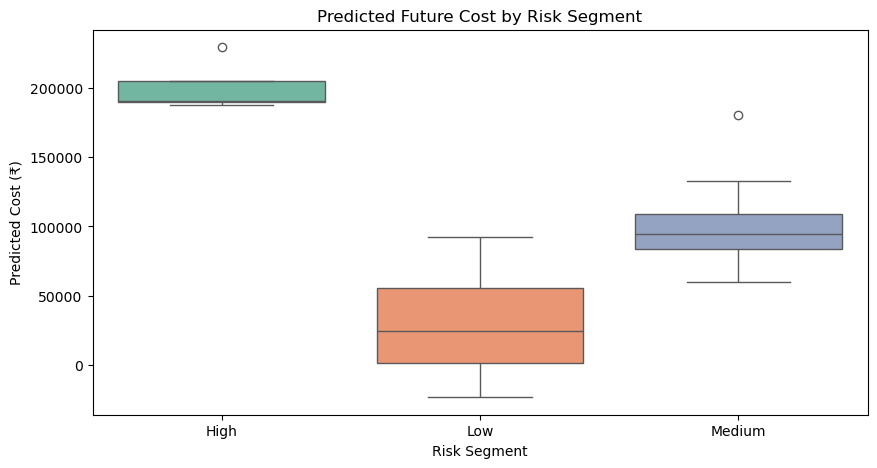

In [69]:
plt.figure(figsize=(10,5))
sns.boxplot(x='risk_label', y='predicted_cost', data=employee_stats, palette='Set2')
plt.title('Predicted Future Cost by Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('Predicted Cost (₹)')
plt.show()


In [71]:
top_cost = employee_stats[['CPF NO', 'predicted_cost', 'risk_label', 'prob_high_claim']].sort_values('predicted_cost', ascending=False).head(10)
display(top_cost)


,CPF NO,predicted_cost,risk_label,prob_high_claim
14,265479,229097.955349,High,0.98
67,755129,204513.259410,High,0.92
8,186107,190395.552979,High,0.95
0,20659,189911.065754,High,0.89
73,786712,187255.048479,High,0.91
80,847119,180461.223185,Medium,0.77
62,717288,132536.146453,Medium,0.14
102,998734,126442.227442,Medium,0.75
60,716123,116945.473255,Medium,0.94
66,753994,115689.447238,Medium,0.88


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16512\4149316680.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='frequent_pred', y='predicted_cost', data=employee_stats, palette='Accent')


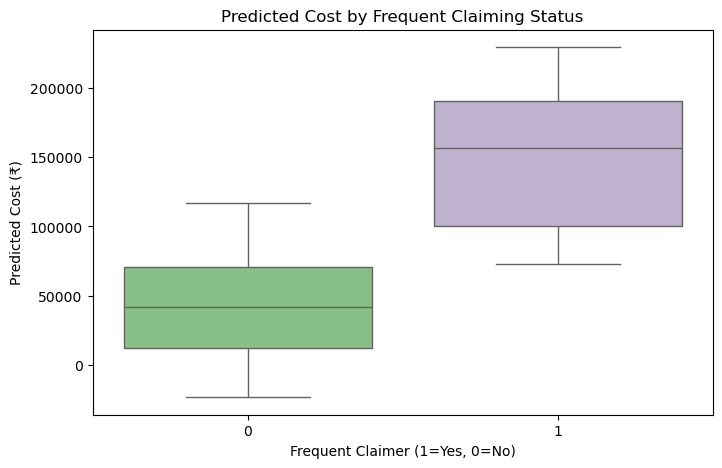

In [73]:
plt.figure(figsize=(8,5))
sns.boxplot(x='frequent_pred', y='predicted_cost', data=employee_stats, palette='Accent')
plt.title('Predicted Cost by Frequent Claiming Status')
plt.xlabel('Frequent Claimer (1=Yes, 0=No)')
plt.ylabel('Predicted Cost (₹)')
plt.show()


In [75]:
segment_means = employee_stats.groupby('risk_label')[['claim_count', 'unique_illness', 'total_amount', 'mean_amount', 'prob_high_claim', 'prob_frequent', 'predicted_cost']].mean().round(1)
display(segment_means)


,claim_count,unique_illness,total_amount,mean_amount,prob_high_claim,prob_frequent,predicted_cost
risk_label,,,,,,,
High,14.4,8.8,233197.0,16630.7,0.9,1.0,200234.6
Low,3.4,3.0,25766.8,7911.9,0.0,0.0,28308.7
Medium,6.7,5.8,98369.2,16234.2,0.6,0.3,97900.5


In [77]:
#--- 8. Recommendations Table ---

import pandas as pd

recommendations = {
    'Risk Segment': ['High', 'Medium', 'Low'],
    'Recommended Action': [
        'Intensive Health Management and Monitoring',
        'Preventive Care and Regular Checkups',
        'Standard Wellness Programs and Awareness'
    ]
}

recommendation_df = pd.DataFrame(recommendations)
print("Actionable Recommendations by Risk Segment:")
display(recommendation_df)


Actionable Recommendations by Risk Segment:


,Risk Segment,Recommended Action
0,High,Intensive Health Management and Monitoring
1,Medium,Preventive Care and Regular Checkups
2,Low,Standard Wellness Programs and Awareness


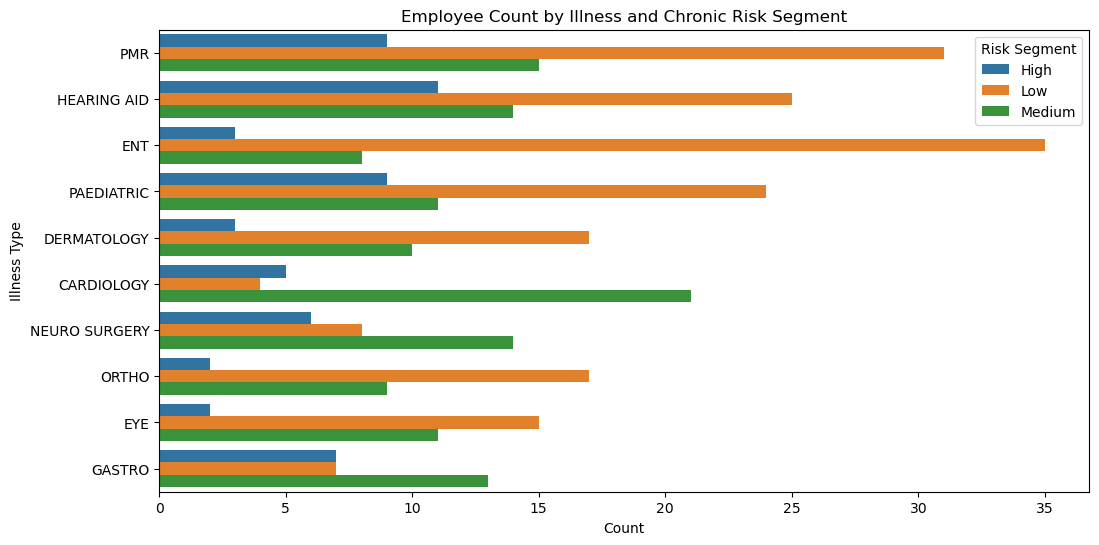

In [79]:
# Assuming you join illness back to the risk-labeled employee_stats
# If employee_stats has only one row per employee, use a groupby merge:
illness_df = df[['CPF NO', 'ILLNESS']]
emp_illness = pd.merge(employee_stats, illness_df, on='CPF NO', how='left')

plt.figure(figsize=(12,6))
sns.countplot(
    y='ILLNESS', 
    hue='risk_label', 
    data=emp_illness, 
    order=emp_illness['ILLNESS'].value_counts().index[:10]  # Top 10 illnesses
)
plt.title("Employee Count by Illness and Chronic Risk Segment")
plt.xlabel("Count")
plt.ylabel("Illness Type")
plt.legend(title="Risk Segment")
plt.show()


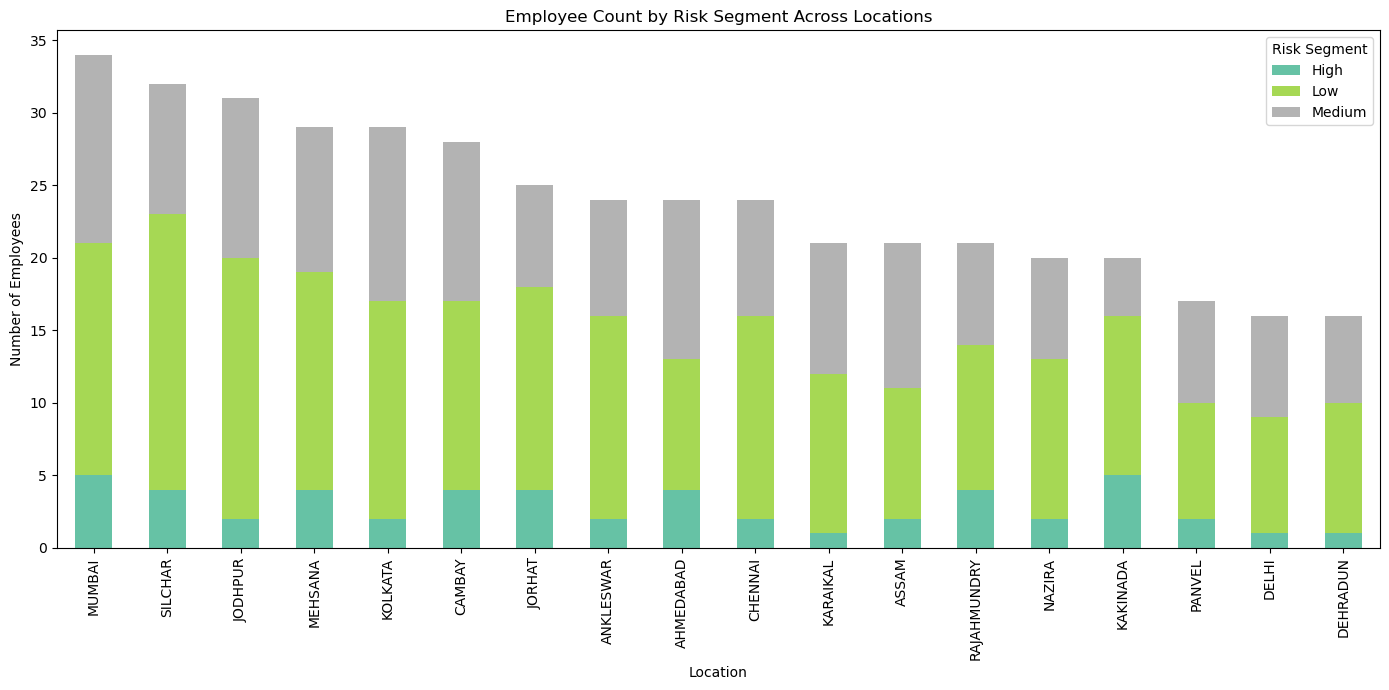

In [81]:
# If employee_stats doesn't include LOCATION, merge it in:
location_map = df[['CPF NO', 'LOCATION']].drop_duplicates()
employee_stats_location = pd.merge(employee_stats, location_map, on='CPF NO', how='left')

# Count employees per location and risk segment
loc_risk_counts = employee_stats_location.groupby(['LOCATION', 'risk_label'])['CPF NO'].count().unstack(fill_value=0)

# Sort locations by total employees for clean display
loc_risk_counts = loc_risk_counts.loc[loc_risk_counts.sum(axis=1).sort_values(ascending=False).index]

# Plot
loc_risk_counts.plot(kind='bar', stacked=True, figsize=(14,7), colormap='Set2')
plt.title('Employee Count by Risk Segment Across Locations')
plt.xlabel('Location')
plt.ylabel('Number of Employees')
plt.legend(title='Risk Segment')
plt.tight_layout()
plt.show()


In [83]:
# Map recommendations
rec_map = {
    'High': 'Intensive Health Management and Monitoring',
    'Medium': 'Preventive Care and Regular Checkups',
    'Low': 'Standard Wellness Programs and Awareness'
}
emp_illness['recommendation'] = emp_illness['risk_label'].map(rec_map)

# Show sample
action_table = emp_illness[['CPF NO', 'risk_label', 'ILLNESS', 'recommendation']].drop_duplicates()
display(action_table.head(20))


,CPF NO,risk_label,ILLNESS,recommendation
0,20659,High,PMR,Intensive Health Management and Monitoring
1,20659,High,HEARING AID,Intensive Health Management and Monitoring
2,20659,High,GASTRO,Intensive Health Management and Monitoring
3,20659,High,PAEDIATRIC,Intensive Health Management and Monitoring
4,20659,High,AIR BED,Intensive Health Management and Monitoring
7,20659,High,NEUROLOGY,Intensive Health Management and Monitoring
8,20659,High,NEURO SURGERY,Intensive Health Management and Monitoring
13,20659,High,GENERAL MEDICINE,Intensive Health Management and Monitoring
15,38367,Low,DERMATOLOGY,Standard Wellness Programs and Awareness
16,38367,Low,ENT,Standard Wellness Programs and Awareness


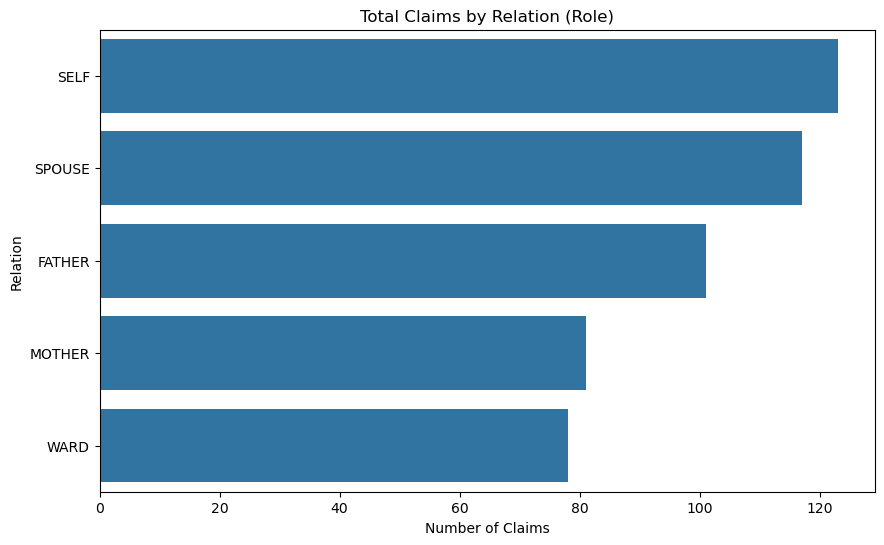

In [85]:
plt.figure(figsize=(10,6))
sns.countplot(y='RELATION', data=df, order=df['RELATION'].value_counts().index)
plt.title('Total Claims by Relation (Role)')
plt.xlabel('Number of Claims')
plt.ylabel('Relation')
plt.show()


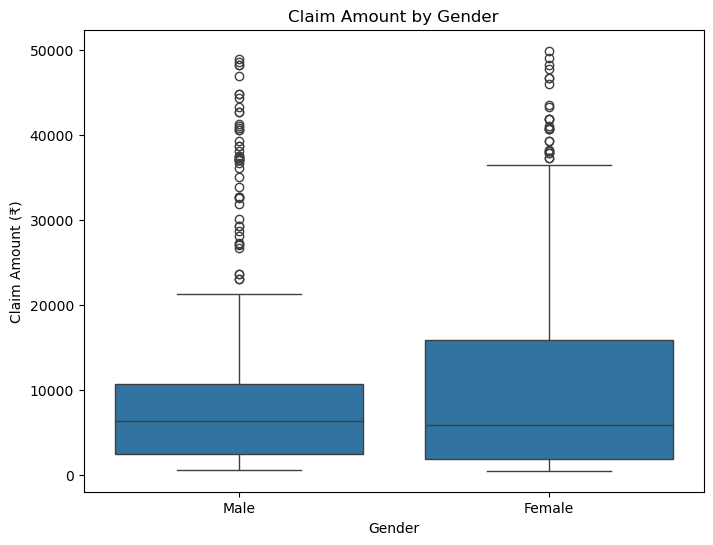

In [87]:
plt.figure(figsize=(8,6))
sns.boxplot(x='GENDER', y='AMOUNT', data=df)
plt.title('Claim Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Claim Amount (₹)')
plt.show()


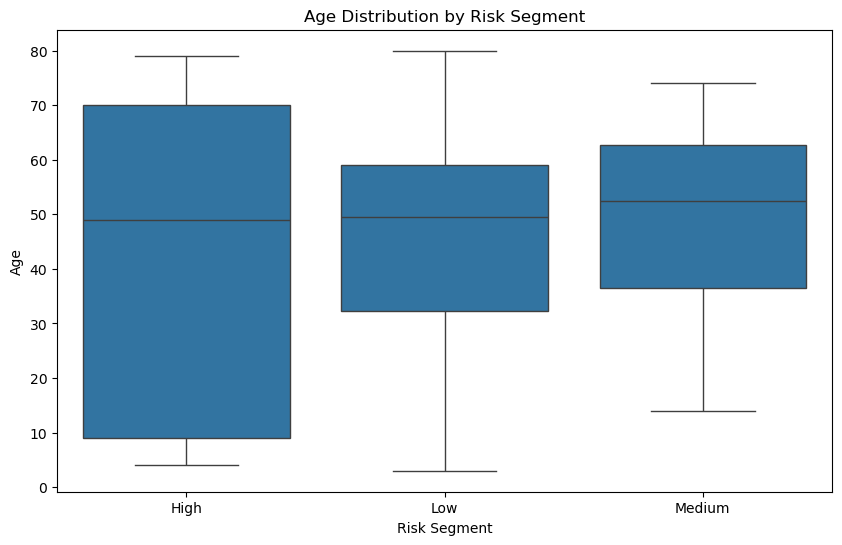

In [89]:
plt.figure(figsize=(10,6))
sns.boxplot(x='risk_label', y='AGE', data=employee_stats)
plt.title('Age Distribution by Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('Age')
plt.show()


In [93]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(employee_stats[cluster_features], employee_stats['risk_segment'])
print(f"Silhouette Score: {sil_score:.2f}")


Silhouette Score: 0.63
